In [2]:
# =========================
# 1. Imports
# =========================

import sys
import os
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

sys.path.append(os.path.abspath(".."))

from src.preprocessing import clean_data

In [3]:
# =========================
# 2. Load data
# =========================

df = pd.read_csv("../data/creditcard.csv")

df = clean_data(df)

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [4]:
# =========================
# 3. Load final model
# =========================

final_model = joblib.load("../models/best_tuned_model.pkl")

In [5]:
# =========================
# 4. Predict probabilities
# =========================

y_proba = final_model.predict_proba(X_test)[:, 1]

In [6]:
# =========================
# 5. Load threshold
# =========================

with open("../models/threshold_config.json", "r") as f:
    threshold_config = json.load(f)

best_threshold = threshold_config["best_threshold"]

print(f"Selected threshold: {best_threshold}")

Selected threshold: 0.6500000000000001


In [7]:
# =========================
# 6. Final predictions
# =========================

y_pred_final = (y_proba >= best_threshold).astype(int)

In [8]:
# =========================
# 7. Final metrics
# =========================

final_results = pd.DataFrame([{
    "Threshold": best_threshold,
    "AUPRC": average_precision_score(y_test, y_proba),
    "ROC_AUC": roc_auc_score(y_test, y_proba),
    "Precision": precision_score(y_test, y_pred_final),
    "Recall": recall_score(y_test, y_pred_final),
    "F1": f1_score(y_test, y_pred_final)
}])

final_results

,Threshold,AUPRC,ROC_AUC,Precision,Recall,F1
0,0.65,0.80173,0.977361,0.933333,0.736842,0.823529


In [9]:
# =========================
# 8. Classification report
# =========================

print(classification_report(
    y_test,
    y_pred_final,
    target_names=["Legit", "Fraud"]
))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.93      0.74      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



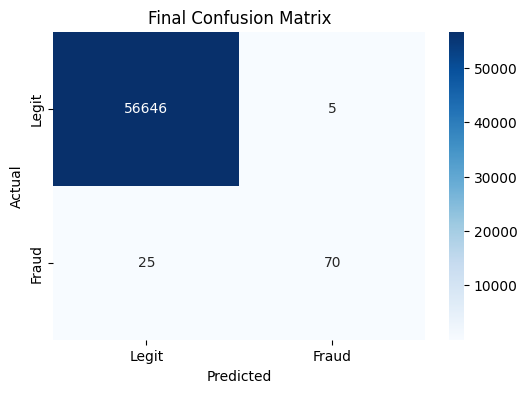

In [10]:
# =========================
# 9. Confusion matrix
# =========================

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legit", "Fraud"],
    yticklabels=["Legit", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix")

plt.show()

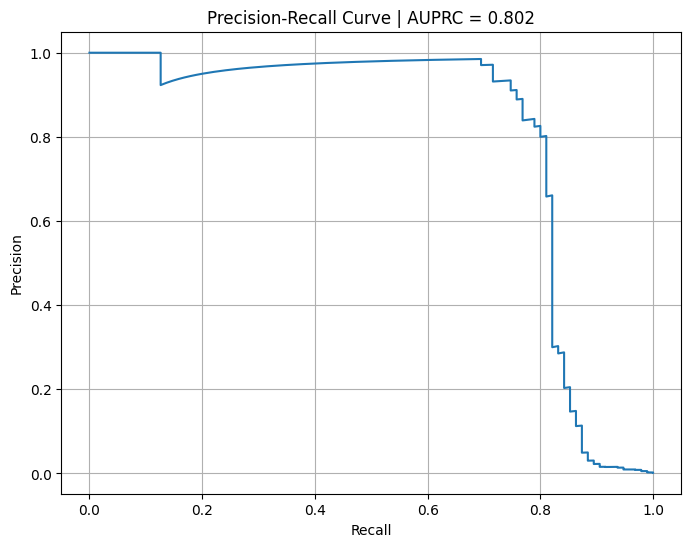

In [11]:
# =========================
# 10. Precision-Recall Curve
# =========================

precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    f"Precision-Recall Curve | AUPRC = {average_precision_score(y_test, y_proba):.3f}"
)

plt.grid(True)
plt.show()

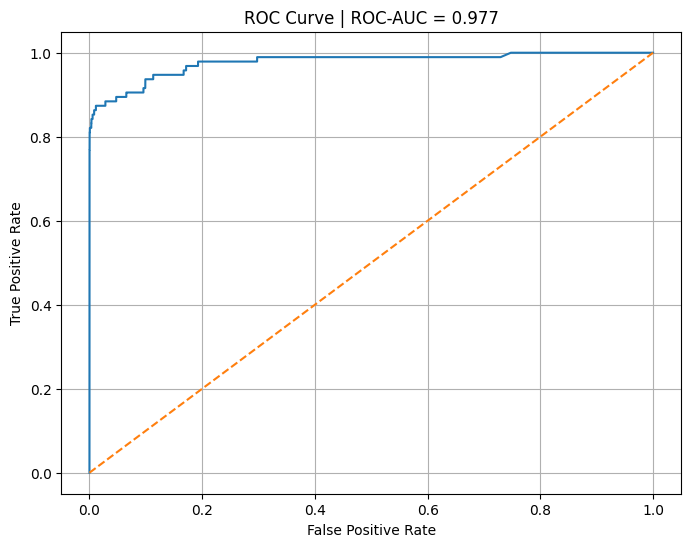

In [12]:
# =========================
# 11. ROC Curve
# =========================

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    f"ROC Curve | ROC-AUC = {roc_auc_score(y_test, y_proba):.3f}"
)

plt.grid(True)
plt.show()

In [14]:
# =========================
# 12. Feature Importance - fixed version
# =========================

model = final_model.named_steps["model"]
importances = model.feature_importances_

# For your tree_time_cyclic pipeline:
# Transformed columns: amount_log, hour_sin, hour_cos
# Remainder columns: original columns not transformed
transformed_features = [
    "Amount_log",
    "Hour_sin",
    "Hour_cos"
]

remainder_features = [
    col for col in X.columns 
    if col not in ["Amount", "Time"]
]

feature_names = transformed_features + remainder_features

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
16,V14,0.173460
12,V10,0.114235
14,V12,0.097029
13,V11,0.093701
6,V4,0.091931
19,V17,0.086809
5,V3,0.041088
9,V7,0.037334
18,V16,0.035321
11,V9,0.029304


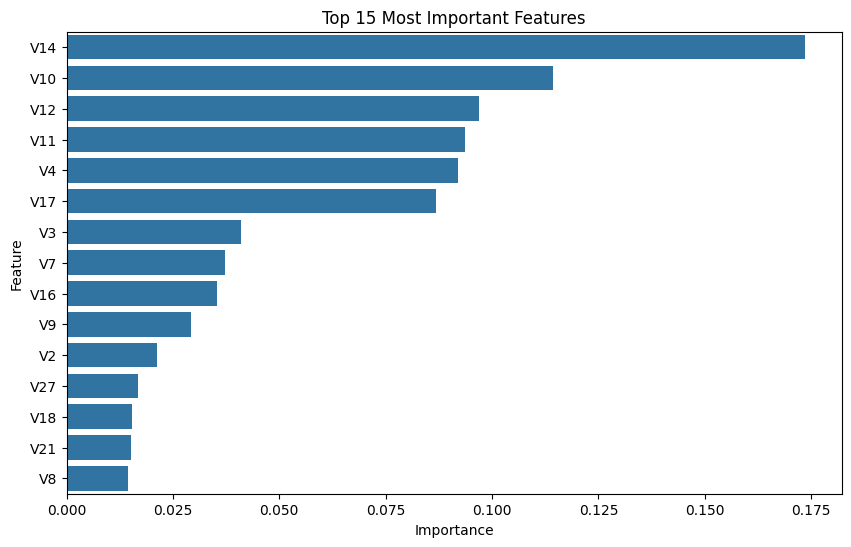

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# Final Model Evaluation

## Precision–Recall Curve Analysis

The Precision–Recall curve evaluates the model's ability to identify fraudulent transactions while maintaining a low false positive rate. Since fraud detection is a highly imbalanced classification problem, the Precision–Recall curve is more informative than accuracy.

The model achieved an **AUPRC of 0.802**, indicating strong performance in distinguishing fraudulent transactions from legitimate ones.

Several observations can be made:

- Precision remains extremely high (above 90%) for a large range of recall values.
- The model is able to detect approximately 70–80% of fraudulent transactions while maintaining a very low false positive rate.
- Precision drops sharply only when recall exceeds approximately 80%, indicating that capturing the remaining fraud cases requires accepting a substantial increase in false alarms.

This behavior confirms that the model provides an effective trade-off between fraud detection capability and operational efficiency.

---

## ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve evaluates the ranking ability of the model across all possible decision thresholds.

The model achieved a **ROC-AUC score of 0.977**, which is considered excellent performance.

The ROC curve remains very close to the upper-left corner of the graph, demonstrating:

- A high True Positive Rate (fraud detection rate).
- A very low False Positive Rate.
- Strong discrimination between fraudulent and legitimate transactions.

A ROC-AUC of 0.977 means that if a random fraudulent transaction and a random legitimate transaction are selected, the model will correctly assign a higher fraud probability to the fraudulent transaction approximately 97.7% of the time.

These results confirm that the Random Forest model has learned meaningful fraud-related patterns and generalizes effectively to unseen data.

---

## Feature Importance Analysis

Feature importance scores reveal which variables contribute most to the fraud detection decision process.

The most influential features are:

| Rank | Feature |
|--------|--------|
| 1 | V14 |
| 2 | V10 |
| 3 | V12 |
| 4 | V11 |
| 5 | V4 |
| 6 | V17 |
| 7 | V3 |
| 8 | V7 |
| 9 | V16 |
| 10 | V9 |

Among all variables, **V14** is by far the most important predictor, followed by **V10**, **V12**, and **V11**.

These variables originate from the PCA transformation applied to the original confidential transaction attributes. Although their business meaning is unknown, their high importance indicates that they capture the strongest fraud-related patterns within the dataset.

Interestingly, the engineered features (Amount_log, Hour_sin, and Hour_cos) do not appear among the most important predictors. This suggests that the PCA-derived variables already contain most of the information necessary to identify fraudulent transactions.

---

## Overall Conclusion

The final tuned Random Forest model demonstrates strong performance on unseen data:

- **AUPRC:** 0.802
- **ROC-AUC:** 0.977
- **Precision:** 93.3%
- **Recall:** 73.7%
- **F1-score:** 82.4%

The selected threshold of **0.65** prioritizes precision, ensuring that most flagged transactions are truly fraudulent while keeping false alarms to a minimum.

Overall, the model successfully balances fraud detection effectiveness and operational practicality, making it suitable for real-world fraud monitoring scenarios where minimizing false positives is critical while still detecting the majority of fraudulent transactions.